In [ ]:
import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.insert(0,homepath)

%load_ext autoreload 
%autoreload 2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import reciprocalspaceship as rs
import pandas as pd
from meteor import rsmap
from meteor.utils import cut_resolution

from logger import setup_logger

logger = setup_logger()

In [3]:
from configuration import load_homepath


In [4]:
from dataset_configs import apply_config_B12_general

config = apply_config_B12_general(3)
config

{'general': {'name_human': 'B12 10ns_30',
  'name_machine': 'B12_10ns_30',
  'output_base_folder': '/Users/sbielfel/Nextcloud2/time_resolved/tmp/diffmap_data/',
  'map_sampling': 3,
  'high_resolution_limit': 2.3,
  'data_type': 'diff'},
 'input_files': {'map_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/b12_sacla/9S06_dark.mtz',
  'map_diff': '/Users/sbielfel/Nextcloud2/time_resolved/data/b12_sacla/10ns_30mJ.cm-2_SACLA_qFoFo.mtz',
  'pdb_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/b12_sacla/9S06.pdb',
  'columns_dark': {'amplitude_column': 'FP',
   'phase_column': 'PHIF-model',
   'uncertainty_column': 'SIGFP'},
  'columns_diff': {'amplitude_column': 'QFOFOWT',
   'uncertainty_column': 'SIGF',
   'phase_column': 'PHIQFOFOWT'}},
 'masking': {'sigma': 3,
  'min_blob_size': 3,
  'blocking_radius': 1.5,
  'blocking_percentile': 95,
  'exclude_solvent': True,
  'dark_size_threshold': 0.1,
  'exclude_positive_diffmap': True,
  'exclude_large_occupancy_outliers': False},
 '

In [5]:
# from alternative_methods import load_xtrapol8_data
# from alternative_methods import gemmi_structure_to_calculated_map
# from processing import autoshift_rsmap, autoshift_rsmap_old
# from meteor import rsmap
# from meteor.scale import scale_maps
# import gemmi
# import copy

# def get_map_dark(config, old = False):
#     ds_dark = rs.read_mtz(config["input_files"]["map_dark"])
#     print(np.min(ds_dark.compute_dHKL()["dHKL"]))
#     struc_dark = gemmi.read_pdb(config["input_files"]["pdb_dark"])
#     map_dark_comp = gemmi_structure_to_calculated_map(
#         struc_dark,
#         high_resolution_limit=config["general"]["high_resolution_limit"],
#     )
#     if config["input_files"]["columns_dark"]["phase_column"] not in ds_dark.columns:
#         phase_col_name = config["input_files"]["columns_dark"]["phase_column"]
#         warning_msg = f"Phase column {phase_col_name} not found in dark dataset. "
#         warning_msg += "Using calculated phases from the PDB structure."
#         logger.warning(warning_msg)
#         ds_dark[phase_col_name] = map_dark_comp.phases
#     map_dark = rsmap.Map(ds_dark, **config["input_files"]["columns_dark"])
#     map_dark.canonicalize_amplitudes()
#     map_dark = cut_resolution(map_dark, high_resolution_limit=config["general"]["high_resolution_limit"])
#     map_dark = scale_maps(reference_map=map_dark_comp, map_to_scale=map_dark)
#     if old:
#         map_dark, shift2 = autoshift_rsmap_old(copy.deepcopy(map_dark), config["general"] | {"pdbloc_dark": config["input_files"]["pdb_dark"]}, map_dark_comp)
#     else:
#         map_dark, shift1 = autoshift_rsmap(copy.deepcopy(map_dark), config["general"] | {"pdbloc_dark": config["input_files"]["pdb_dark"]}, map_dark_comp)
#     return map_dark

# def get_maps_diff(config, map_dark=None, old = False):
#     if map_dark is None:
#         map_dark = get_map_dark(config, old)
#     else:
#         map_dark = copy.deepcopy(map_dark)

#     ds_diff = rs.read_mtz(config["input_files"]["map_diff"])
#     diffmap = rsmap.Map(ds_diff, **config["input_files"]["columns_diff"])
#     compute_dHKL = ds_diff.compute_dHKL()
#     dmin = np.min(compute_dHKL["dHKL"])
#     map_dark = cut_resolution(map_dark, high_resolution_limit=dmin)
#     return map_dark, diffmap



# # data = load_xtrapol8_data(xtrapolate_pickle)

In [6]:
map_dark_base = None

2026-03-14 12:52:06,836: logger: WARNING: Phase column PHIF-model not found in dark dataset. Using calculated phases from the PDB structure. (processing.py:770)


2.0500147
--- Calibrating Absolute Densities for /Users/sbielfel/Nextcloud2/time_resolved/data/b12_sacla/9S06.pdb ---
Generating protein and solvent masks...
Estimated rho_atom offset (mean shift inside protein): 0.30654
Running 1D bounded optimization for rho_bulk...


2026-03-14 12:52:15,949: logger: INFO: 
                              --- Calibration Complete --- (processing.py:504)
2026-03-14 12:52:15,950: logger: WARNING: Estimated rho_atom shift (0.3065) and combined rho (rho_atom + share_solvent * rho_bulk) (0.2962 0.1882+0.4514*0.2392) differ by more than 0.01 e-/Å³. This may indicate an issue with the estimation or the maps. (processing.py:541)
2026-03-14 12:52:16,028: logger: WARNING: Used threshold for posmask: 0.230, found 1346 blobs (masking.py:133)
2026-03-14 12:52:16,034: logger: INFO: Using blobs with more than 7.819313263925526(3 A^3) voxels (masking.py:150)
2026-03-14 12:52:16,034: logger: INFO: Maximum Blob sizes found: 151 (masking.py:151)


Optimal rho_bulk: 0.2392 e-/Å³


2026-03-14 12:52:16,159: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 32 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-03-14 12:52:16,251: logger: INFO: Excluding 4 (0.06%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-03-14 12:52:16,280: logger: INFO: Excluding an addtional 92 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:268)
2026-03-14 12:52:16,307: logger: WARNING: Excluding an addtional 12 voxels from mask duedark map smaller than mean + 0 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:299)
2026-03-14 12:52:16,307: logger: WARNING: Excluding voxels with positive difference density from mask (activate via 'exclude_positive_diffmap' parameter) (masking.py:302)
2026-0

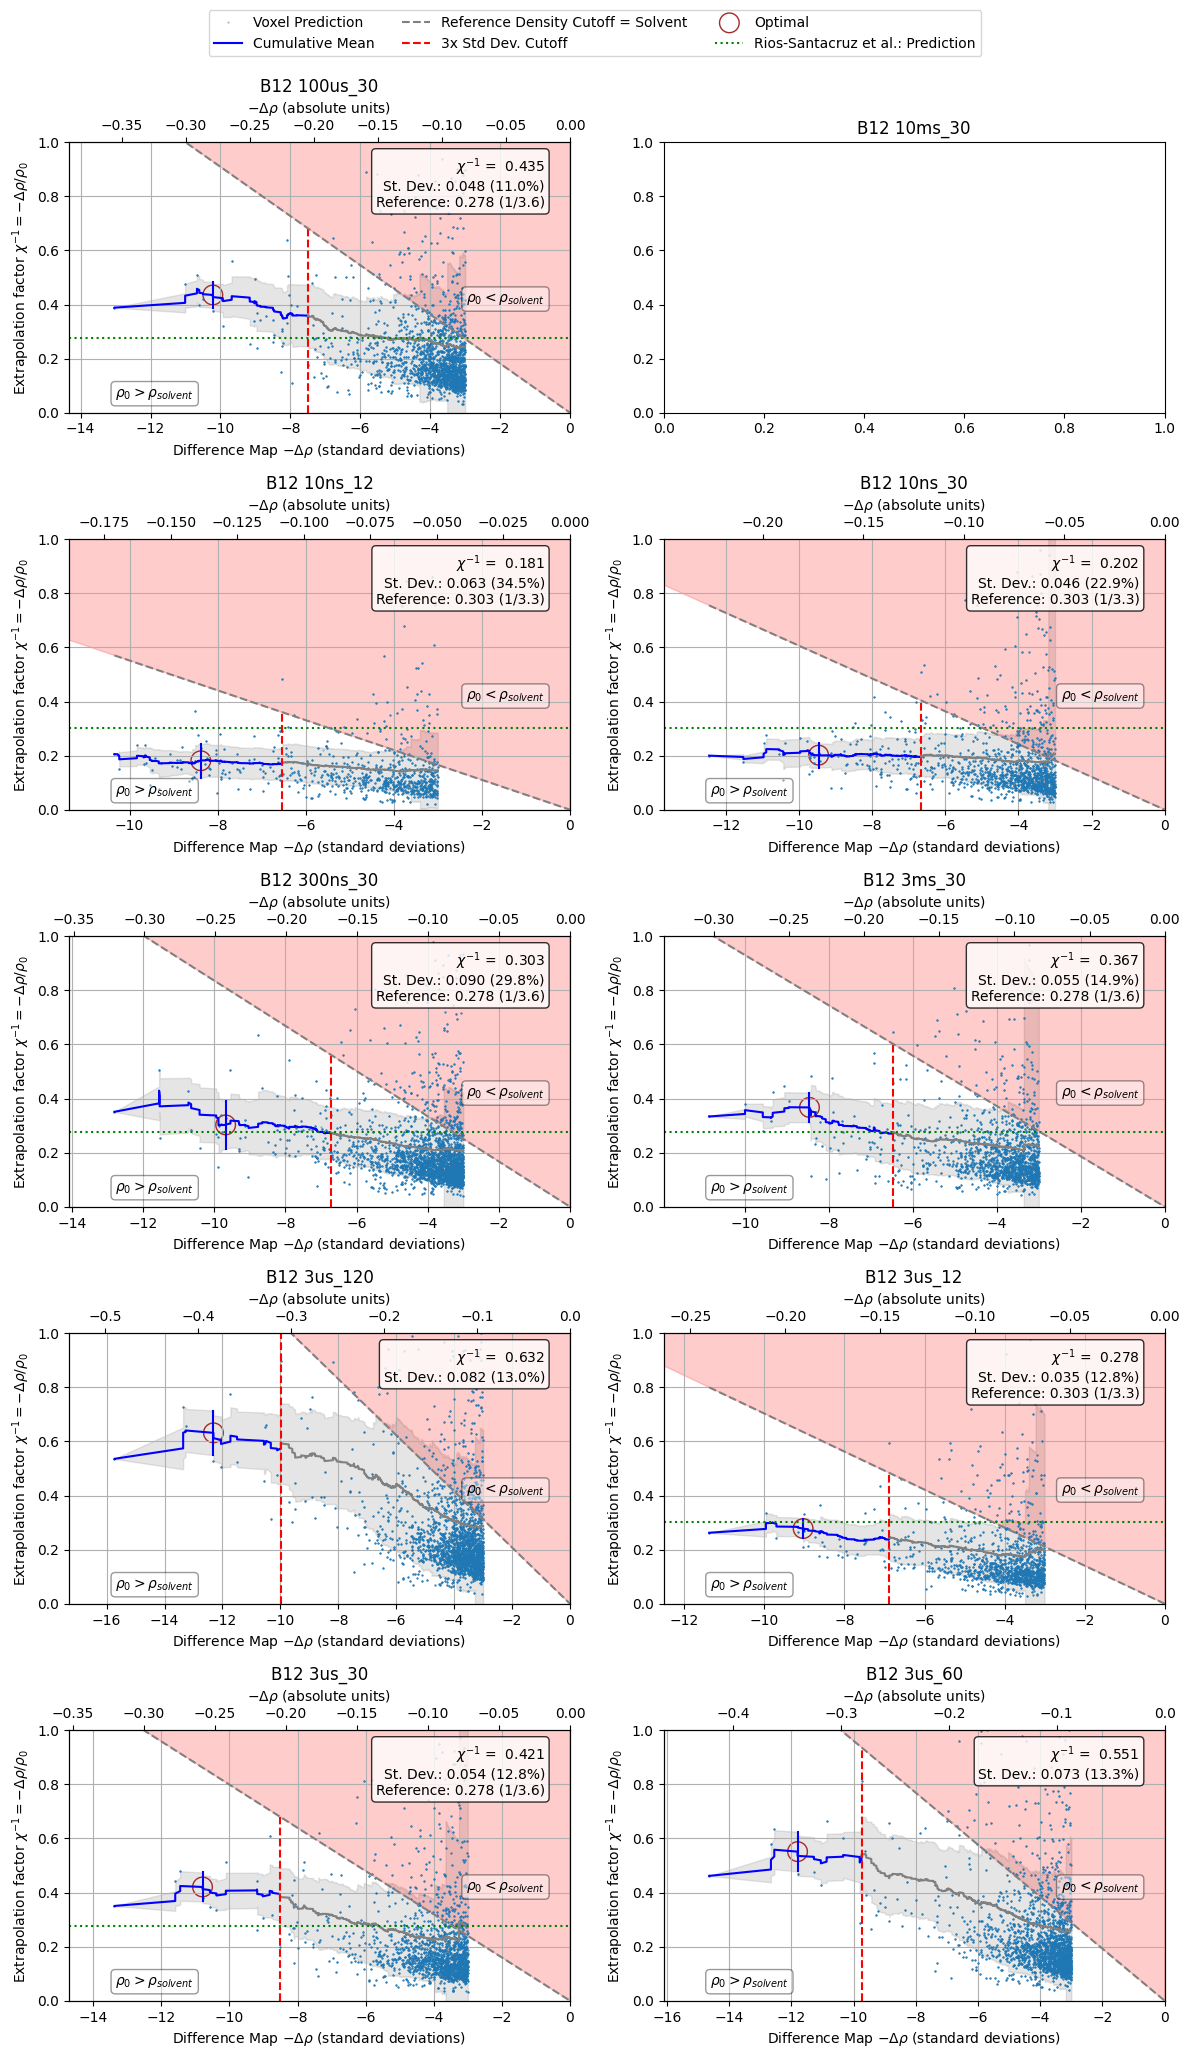

In [7]:
import numpy as np
from masking import make_inclusion_mask
from estimation import plot_extrapolation_estimate_new
from processing import get_maps_diff, get_map_dark
# 1. Create the main figure
fig,axs = plt.subplots(5,2, figsize=(12, 20), tight_layout=True)

if map_dark_base is None:
    config = apply_config_B12_general(0)
    map_dark_base, diffmap = get_maps_diff(config)

pred_33 = ["10ns_12","10ns_30", "3us_12"]
pred_36 = ["300ns_30","100us_30", "3us_30", "3ms_30"]


# 2. Define the 2x2 outer grid
for i, ax in enumerate(axs.flatten()):

    config = apply_config_B12_general(i)
    ax.set_title(config["general"]["name_human"])
    if i == 1:
        continue
    
    config["masking"]["dark_size_threshold"] = 0
    map_dark, diffmap = get_maps_diff(config, map_dark=map_dark_base)
    inclusion_mask_nse = make_inclusion_mask(diffmap, map_dark, config)

    if config["general"]["name_human"].split(" ")[-1] in pred_33:
        config["plot"]["comparison_to_reference"] = dict(
            value=(1/3.3), label = "Prediction: $\\chi^{-1}=1/3.3$"
        )
    if config["general"]["name_human"].split(" ")[-1] in pred_36:
        config["plot"]["comparison_to_reference"] = dict(
            value=(1/3.6), label = "Prediction: $\\chi^{-1}=1/3.6$"
        )

    plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask_nse, config, ax)

    if config["general"]["name_human"].split(" ")[-1] in pred_33:
        ax.axhline(1/3.3, color="green", linestyle=":", label="Rios-Santacruz et al.: Prediction")
    if config["general"]["name_human"].split(" ")[-1] in pred_36:
        ax.axhline(1/3.6, color="green", linestyle=":", label="Rios-Santacruz et al.: Prediction")
# axs[0].set_xlim(0,1)
    ax.set_ylim(0,1)
    # break
    # ax.legend(loc="upper left")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, 
    loc='upper center', 
    ncol=3,             # Adjust ncol to spread them horizontally
    bbox_to_anchor=(0.5, 1.03)) # Moves it above the subplots

# 3. Use tight_layout but leave room at the top for the legend
plt.tight_layout()


In [100]:
# from configuration import load_figurepath
# from masking import make_inclusion_mask
# from estimation import plot_extrapolation_estimate_new
# from configuration import minimal_masking_config
# import copy

# # 1. Create the main figure
# fig,axs = plt.subplots(4,2, figsize=(12, 20), tight_layout=True)
# map_dark_base_false = copy.deepcopy(map_dark_base)
# # print(map_dark_base_false.loc[(0,0,0)])
# # map_dark_base_false.loc[(0,0,0)] *= 0.8
# # 2. Define the 2x2 outer grid
# for i, ax in enumerate(axs.flatten()):
#     if i == 1:
#         continue

#     config = apply_config_B12_general(i)
#     config["masking"]["exclude_large_occupancy_outliers"] = False
#     config["masking"]["dark_size_threshold"] = 0
    
#     map_dark, diffmap = get_maps_diff(config, map_dark=map_dark_base_false)
#     config_nse = copy.deepcopy(config)
#     # config_nse["masking"] = minimal_masking_config()
#     map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
#     diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
#     print(f"Config {i}: map_dark_np shape: {map_dark_np.shape}, diffmap_np shape: {diffmap_np.shape}")
#     print(f"Config {i}: map_dark unit cell: {map_dark.cell}, diffmap unit cell: {diffmap.cell}")
#     print(f"Config {i}: map_dark space group: {map_dark.spacegroup}, diffmap space group: {diffmap.spacegroup}")
#     inclusion_mask_nse = make_inclusion_mask(diffmap, map_dark, config_nse)

#     plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask_nse, config, ax)
#     ax.set_title(config["general"]["name_human"])
# # axs[0].set_xlim(0,1)
# # axs[0].set_ylim(0,0.81)

<unknown>:562: SyntaxWarning: invalid escape sequence '\c'
<unknown>:562: SyntaxWarning: invalid escape sequence '\c'
